In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import sklearn
import time
import os
import sys



# 1. Get the absolute path of the folder two levels up (your main project folder)
project_root = os.path.abspath("../../")

# 2. Add that project folder to Python's search path
if project_root not in sys.path:
    sys.path.append(project_root)

# 3. NOW you can import using standard dot notation!
import src.features as ft
import src.evaluation as ev


d:\AI\Stock Analysis\trading_system\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

FILE_URL = "../../data/market_data.parquet"
df = pd.read_parquet(FILE_URL)
df = df[df["close"] > 0]
df.head()

,date,open,high,low,close,volume,Symbol
0,2017-08-08,4.63,4.65,4.55,4.56,382940,ACB
1,2017-08-09,4.56,4.56,4.46,4.49,1649412,ACB
2,2017-08-10,4.46,4.51,4.44,4.46,1139760,ACB
3,2017-08-11,4.48,4.48,4.44,4.46,774623,ACB
4,2017-08-14,4.44,4.51,4.44,4.51,657975,ACB


In [3]:
df = ft.build_features(df)
df = ft.target_generating_ranking(df)

In [4]:
df.head()

,date,open,high,low,close,volume,Symbol,log_ret_1w,log_ret_1m,log_ret_3m,...,vol_21d_avg,vol_3m_avg,volume_surge_monthly,volume_surge_weekly,RSI_14,next_1m_ret,next_1w_ret,qid,risk_adj_ret,target_quintile
105283,2018-08-07,33.76,34.78,33.70,34.48,29410,PAN,0.059129,0.030168,-0.102732,...,3.742048e+04,4.710921e+04,0.794335,2.184686,52.623381,0.008663,0.010387,0,0.025401,0
152842,2018-08-07,12.27,12.34,12.14,12.14,613455,VGC,0.005721,0.074421,-0.291952,...,1.632681e+06,2.152275e+06,0.758584,0.640552,41.543374,0.114299,0.037191,0,0.194912,2
162416,2018-08-07,1.56,1.56,1.52,1.54,41011,VIX,0.045910,0.159507,0.080043,...,1.459688e+05,1.336584e+05,1.092104,1.113817,59.069197,0.087011,0.000000,0,0.200560,4
9440,2018-08-08,6.54,6.81,6.54,6.59,88440,BSI,-0.016680,0.043757,-0.171045,...,7.727238e+04,9.523667e+04,0.811372,0.622033,49.057782,-0.033954,0.000000,1,-0.097260,0
28392,2018-08-08,5.39,5.54,5.39,5.42,21800,DBC,-0.045542,-0.042111,0.197490,...,2.229505e+04,4.469090e+04,0.498872,0.587888,43.844799,0.195458,0.041560,1,0.406814,4


In [5]:


# Define your features and target
features = [
    'log_ret_1m', 'log_ret_3m', 'log_ret_1y',  
    'volatility_shock_monthly', 'volatility_3m',         
    'dist_SMA_100',                          
    'RSI_14','volume_surge_monthly'
]





X_train,y_train,qids_train,X_test,y_test,qids_test,test_df = ft.test_train_spliter(df,'2025-01-01',features)
# 2. Initialize the Ranker
# objective='rank:pairwise' minimizes the number of inversions in the ranking
# objective='rank:ndcg' puts heavier emphasis on getting the very top ranks correct
ranker = xgb.XGBRanker(**ft.base_model())

ranker.fit(
    X=X_train, 
    y=y_train, 
    qid=qids_train,                # Tells XGBoost which rows belong to the same "date"
    eval_set=[(X_test, y_test)],   # Optional: lets you see performance during training
    eval_qid=[qids_test],          # Required if you use eval_set
    verbose=True
)

[0]	validation_0-ndcg@32:0.42584
[1]	validation_0-ndcg@32:0.44366
[2]	validation_0-ndcg@32:0.45182
[3]	validation_0-ndcg@32:0.44847
[4]	validation_0-ndcg@32:0.44490
[5]	validation_0-ndcg@32:0.44724
[6]	validation_0-ndcg@32:0.44508
[7]	validation_0-ndcg@32:0.43938
[8]	validation_0-ndcg@32:0.44296
[9]	validation_0-ndcg@32:0.44554
[10]	validation_0-ndcg@32:0.44324
[11]	validation_0-ndcg@32:0.44638
[12]	validation_0-ndcg@32:0.44651
[13]	validation_0-ndcg@32:0.44711
[14]	validation_0-ndcg@32:0.44507
[15]	validation_0-ndcg@32:0.44575
[16]	validation_0-ndcg@32:0.44437
[17]	validation_0-ndcg@32:0.44385
[18]	validation_0-ndcg@32:0.44202
[19]	validation_0-ndcg@32:0.44210
[20]	validation_0-ndcg@32:0.44094
[21]	validation_0-ndcg@32:0.44127
[22]	validation_0-ndcg@32:0.44035
[23]	validation_0-ndcg@32:0.44187
[24]	validation_0-ndcg@32:0.44173
[25]	validation_0-ndcg@32:0.44134
[26]	validation_0-ndcg@32:0.44239
[27]	validation_0-ndcg@32:0.44206
[28]	validation_0-ndcg@32:0.44218
[29]	validation_0-ndcg@3

,objective,'rank:ndcg'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


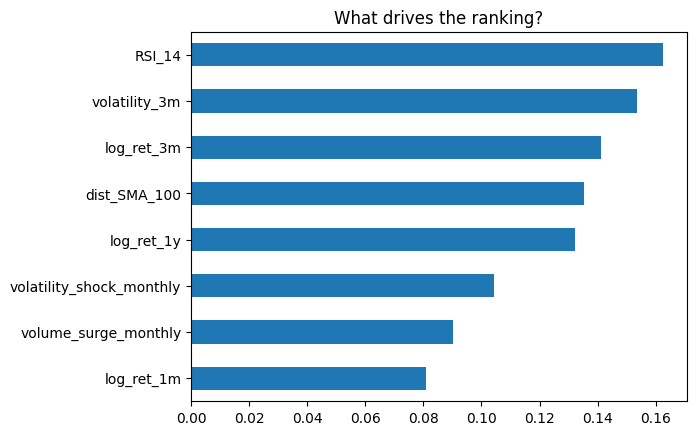

In [6]:
ev.feature_influence(ranker,features)

In [7]:

results = ev.evaluate_ranking_performance(test_df, X_test, ranker)

--- Backtest Results (Top 20% Picks) ---
Top Picks Win Rate:   55.16%
Market Baseline:      53.32%
Excess Win Rate:      +1.84%


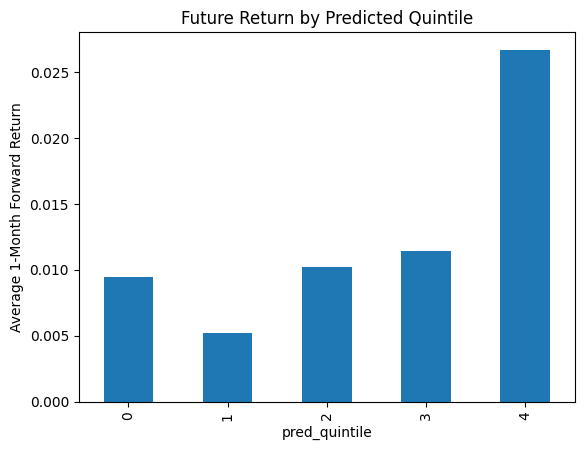

In [8]:
ev.predicted_quintile_chart(test_df,X_test,ranker)

In [9]:
#ranker.save_model('vnindex_ranker_model_monthly.json')